# MVP v0.2.5.14e: 12-Policy Action Scale Sweep (0.03–0.5)

**Date:** 2026-03-26  
**Builds on:** v0.2.5.14b (12 policies, rho=0.21 at scale=0.01), v0.2.5.14c (6-policy sweep)  

Sweep action_scale in [0.03, 0.05, 0.1, 0.2, 0.3, 0.5] on all 12 target policies.  
Test whether stronger guidance can recover ranking on the full 12-policy set.

In [1]:
%matplotlib inline
import sys, os, importlib
import numpy as np
import torch
import torch.nn as nn
import h5py, json, math, time
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.diffusion import GaussianDiffusion
from opelab.core.baselines.diffusion.helpers import EMA, apply_conditioning
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils

import latent_sope.robomimic_interface.guidance as _guidance_mod
importlib.reload(_guidance_mod)
from latent_sope.robomimic_interface.checkpoints import (
    load_checkpoint, build_algo_from_checkpoint
)
from latent_sope.robomimic_interface.guidance import RobomimicDiffusionScorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
CKPT_BASE = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models"
DEMO_HDF5 = PROJECT_ROOT / "third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5"
TARGET_ROLLOUT_DIR = PROJECT_ROOT / "rollouts" / "target_policy_50"
DIFFUSION_SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "mvp_v0252_traj_mse"
ORACLE_JSON = PROJECT_ROOT / "results/2026-03-12/oracle_eval_all_checkpoints.json"
OBS_KEYS = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

STATE_DIM = 19
ACTION_DIM = 7
TRANSITION_DIM = 26
CUBE_Z_INDEX = 2
LIFT_THRESHOLD = 0.84
CHUNK_SIZE = 4
N_DIFFUSION_STEPS = 256
BASE_DIM = 32
DIM_MULTS = (1, 4, 8)
ACTION_WEIGHT = 5.0
NUM_SYNTHETIC = 50
T_GEN = 60
GAMMA = 1.0
SCORE_TIMESTEP = 5
SIGMOID_SHARPNESS = 150.0

# Sweep config
ACTION_SCALES = [0.03, 0.05, 0.1, 0.2, 0.3, 0.5]

TARGET_POLICIES = [
    {"name": "50demos_epoch10",  "dir": "lift_diffusion_50demos/20260311134204",  "ckpt": "models/model_epoch_10.pth"},
    {"name": "10demos_epoch10",  "dir": "lift_diffusion_10demos/20260311115828",  "ckpt": "models/model_epoch_10.pth"},
    {"name": "200demos_epoch10", "dir": "lift_diffusion_200demos/20260311141036", "ckpt": "models/model_epoch_10.pth"},
    {"name": "200demos_epoch20", "dir": "lift_diffusion_200demos/20260311141036", "ckpt": "models/model_epoch_20.pth"},
    {"name": "100demos_epoch20", "dir": "lift_diffusion_100demos/20260311135551", "ckpt": "models/model_epoch_20.pth"},
    {"name": "test_checkpoint",  "dir": "test/20260309132349",                   "ckpt": "last.pth"},
    {"name": "50demos_epoch20",  "dir": "lift_diffusion_50demos/20260311134204",  "ckpt": "models/model_epoch_20.pth"},
    {"name": "10demos_epoch30",  "dir": "lift_diffusion_10demos/20260311115828",  "ckpt": "models/model_epoch_30.pth"},
    {"name": "100demos_epoch30", "dir": "lift_diffusion_100demos/20260311135551", "ckpt": "models/model_epoch_30.pth"},
    {"name": "50demos_epoch30",  "dir": "lift_diffusion_50demos/20260311134204",  "ckpt": "models/model_epoch_30.pth"},
    {"name": "50demos_epoch40",  "dir": "lift_diffusion_50demos/20260311134204",  "ckpt": "models/model_epoch_40.pth"},
    {"name": "200demos_epoch40", "dir": "lift_diffusion_200demos/20260311141036", "ckpt": "models/model_epoch_40.pth"},
]

print(f"Sweep: {ACTION_SCALES}")
print(f"{len(TARGET_POLICIES)} policies x {len(ACTION_SCALES)} scales = {len(TARGET_POLICIES)*len(ACTION_SCALES)} guided runs")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda
Sweep: [0.03, 0.05, 0.1, 0.2, 0.3, 0.5]
12 policies x 6 scales = 72 guided runs


In [2]:
# ── Reward + OPE functions ──
def hard_reward(cube_z):
    return (cube_z > LIFT_THRESHOLD).astype(np.float32)

def sigmoid_reward(cube_z, center=LIFT_THRESHOLD, sharpness=SIGMOID_SHARPNESS):
    return (1.0 / (1.0 + np.exp(-sharpness * (cube_z - center)))).astype(np.float32)

def compute_ope_hard(states, gamma=1.0):
    cube_z = states[:, :, CUBE_Z_INDEX]
    return (hard_reward(cube_z) * (gamma ** np.arange(states.shape[1]))[None, :]).sum(axis=1)

def compute_ope_sigmoid(states, gamma=1.0):
    cube_z = states[:, :, CUBE_Z_INDEX]
    return (sigmoid_reward(cube_z) * (gamma ** np.arange(states.shape[1]))[None, :]).sum(axis=1)

def compute_sr_hard(states):
    cube_z = states[:, :, CUBE_Z_INDEX]
    return np.mean([np.any(cube_z[j] > LIFT_THRESHOLD) for j in range(states.shape[0])])

print("Functions defined.")

Functions defined.


In [3]:
# ── Load oracle ──
with open(ORACLE_JSON, "r") as f:
    oracle_all = json.load(f)

oracle_sr_map = {}
for pol in TARGET_POLICIES:
    name = pol["name"]
    if name == "test_checkpoint":
        with open(CKPT_BASE / "test/20260309132349/oracle_50.json", "r") as f:
            test_oracle = json.load(f)
        oracle_sr_map[name] = float(test_oracle["mean_return"])
    else:
        oracle_sr_map[name] = float(oracle_all[name]["mean_return"])

print("Oracle SR:")
for name, sr in sorted(oracle_sr_map.items(), key=lambda x: x[1]):
    print(f"  {name:<22} {sr*100:>5.0f}%")

Oracle SR:
  50demos_epoch10            0%
  10demos_epoch10            8%
  200demos_epoch10          18%
  200demos_epoch20          24%
  100demos_epoch20          42%
  test_checkpoint           54%
  50demos_epoch20           60%
  10demos_epoch30           62%
  100demos_epoch30          72%
  50demos_epoch30           82%
  50demos_epoch40           88%
  200demos_epoch40          90%


In [4]:
# ── Load data + normalization + diffuser ──
all_states_list, all_actions_list = [], []
target_data = []
for path in sorted(TARGET_ROLLOUT_DIR.glob("rollout_*.h5"))[:50]:
    with h5py.File(path, "r") as f:
        latents = f["latents"][:]
        actions = f["actions"][:]
    states = (latents[:, -1, :] if latents.ndim == 3 else latents).astype(np.float32)
    actions = actions.astype(np.float32)
    target_data.append({"states": states, "actions": actions})
    all_states_list.append(states)
    all_actions_list.append(actions)

with h5py.File(DEMO_HDF5, "r") as f:
    for dk in sorted(f["data"].keys(), key=lambda x: int(x.split("_")[1])):
        demo = f[f"data/{dk}"]
        states = np.concatenate([demo["obs"][k][:].astype(np.float32) for k in OBS_KEYS], axis=-1)
        actions = demo["actions"][:].astype(np.float32)
        all_states_list.append(states)
        all_actions_list.append(actions)

all_states = np.concatenate(all_states_list, axis=0)
all_actions = np.concatenate(all_actions_list, axis=0)
norm_mean = np.concatenate([all_states.mean(0), all_actions.mean(0)]).astype(np.float32)
norm_std = np.maximum(np.concatenate([all_states.std(0), all_actions.std(0)]), 1e-6).astype(np.float32)
norm_mean_t = torch.tensor(norm_mean, device=device)
norm_std_t = torch.tensor(norm_std, device=device)
normalize_fn = lambda x: (x - norm_mean_t) / norm_std_t
unnormalize_fn = lambda x: x * norm_std_t + norm_mean_t

initial_states_t = torch.tensor(
    np.array([ep["states"][0] for ep in target_data[:NUM_SYNTHETIC]]),
    dtype=torch.float32, device=device
)

temporal_model = TemporalUnet(
    horizon=CHUNK_SIZE, transition_dim=TRANSITION_DIM,
    dim=BASE_DIM, dim_mults=DIM_MULTS, attention=False,
).to(device)
diffusion_model = GaussianDiffusion(
    model=temporal_model, horizon=CHUNK_SIZE,
    observation_dim=STATE_DIM, action_dim=ACTION_DIM,
    n_timesteps=N_DIFFUSION_STEPS,
    normalizer=normalize_fn, unnormalizer=unnormalize_fn,
    predict_epsilon=False, loss_type="l2",
    clip_denoised=False, action_weight=ACTION_WEIGHT,
).to(device)
ema = EMA(diffusion_model)
ema.ema_model.load_state_dict(
    torch.load(DIFFUSION_SAVE_DIR / "diffusion_model_ema.pt", map_location=device)
)
print(f"Loaded diffuser. Initial states: {initial_states_t.shape}")

[ models/temporal ] Channel dimensions: [(26, 32), (32, 128), (128, 256)]
[(26, 32), (32, 128), (128, 256)]
Loaded diffuser. Initial states: torch.Size([50, 19])


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


In [5]:
# ── Build paired real trajectory array for state-based logRMSE ──
real_states_list = []
for ep in target_data[:NUM_SYNTHETIC]:
    s = ep["states"]
    T = len(s)
    if T >= T_GEN:
        real_states_list.append(s[:T_GEN])
    else:
        padded = np.zeros((T_GEN, STATE_DIM), dtype=np.float32)
        padded[:T] = s
        padded[T:] = s[-1]
        real_states_list.append(padded)
real_states = np.array(real_states_list)
print(f"Real states for comparison: {real_states.shape}")

Real states for comparison: (50, 60, 19)


In [6]:
# ── Trajectory generator ──
def generate_trajectories(
    diffusion_model, initial_states,
    normalize_fn, unnormalize_fn,
    state_dim, action_dim, chunk_size, t_gen, device,
    target_scorer=None, action_scale=0.0, normalize_grad=True,
):
    guided = (target_scorer is not None and action_scale > 0)
    B = initial_states.shape[0]
    td = state_dim + action_dim
    n_ts = diffusion_model.n_timesteps

    pad = torch.cat([initial_states, torch.zeros(B, action_dim, device=device)], 1)
    cond_init = normalize_fn(pad)[:, :state_dim]
    all_traj = torch.zeros(B, t_gen, td, device=device)
    conditions = {0: cond_init}
    total = 0

    while total < t_gen:
        x = torch.randn(B, chunk_size, td, device=device)
        x = apply_conditioning(x, conditions, state_dim)
        for t_d in reversed(range(n_ts)):
            t_t = torch.full((B,), t_d, device=device, dtype=torch.long)
            with torch.no_grad():
                mm, _, mlv = diffusion_model.p_mean_variance(x=x, t=t_t)
                ms = torch.exp(0.5 * mlv)
            if guided:
                mm = unnormalize_fn(mm)
                sc = mm[:, :, :state_dim]
                ac = mm[:, :, state_dim:]
                tg = target_scorer.grad_log_prob_chunk(sc, ac)
                if normalize_grad:
                    tg = tg / (tg.norm(dim=-1, keepdim=True) + 1e-6)
                guide = torch.zeros_like(mm)
                guide[:, :, state_dim:] = tg
                mm = mm + action_scale * guide
                mm = normalize_fn(mm)
                mm = apply_conditioning(mm, conditions, state_dim)
                mm = unnormalize_fn(mm)
                mm = normalize_fn(mm)
            noise = torch.randn_like(x)
            x = mm + (1 - (t_d == 0) * 1.0) * ms * noise
            x = apply_conditioning(x, conditions, state_dim)
        chunk_u = unnormalize_fn(x)
        n_store = min(chunk_size - 1, t_gen - total)
        all_traj[:, total:total+n_store] = chunk_u[:, 1:1+n_store]
        total += n_store
        if total < t_gen:
            conditions = {0: x[:, -1, :state_dim]}
    return all_traj.cpu().numpy()

print("Generator ready.")

Generator ready.


In [7]:
# ── Pre-load all target scorers (load each checkpoint once) ──
target_scorers = {}
for pol in TARGET_POLICIES:
    name = pol["name"]
    run_dir = CKPT_BASE / pol["dir"]
    print(f"Loading {name}...", end=" ", flush=True)
    t0 = time.time()
    ckpt = load_checkpoint(run_dir, ckpt_path=Path(pol["ckpt"]))
    target_algo = build_algo_from_checkpoint(ckpt, device=str(device))
    target_scorers[name] = RobomimicDiffusionScorer(
        target_algo, device=str(device), score_timestep=SCORE_TIMESTEP, obs_keys=OBS_KEYS
    )
    print(f"{time.time()-t0:.0f}s")
print(f"\nAll {len(target_scorers)} scorers loaded.")

Loading 50demos_epoch10... 


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_gripper_qpos', 'robot0_eef_quat', 'robot0_eef_pos', 'object']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


[14:05:26] INFO     build_algo_from_checkpoint took 0.40 seconds to execute                           ]8;id=728766;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=595781;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

18s
Loading 10demos_epoch10... 

...

11s
Loading 200demos_epoch40... 


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_gripper_qpos', 'robot0_eef_quat', 'robot0_eef_pos', 'object']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


[14:06:31] INFO     build_algo_from_checkpoint took 0.39 seconds to execute                           ]8;id=667999;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=259073;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

1s

All 12 scorers loaded.


In [8]:
# ── Generate unguided baseline (once) ──
print("Generating unguided trajectories...")
np.random.seed(42)
torch.manual_seed(42)
t0 = time.time()
unguided_trajs = generate_trajectories(
    diffusion_model=ema.ema_model, initial_states=initial_states_t,
    normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
    state_dim=STATE_DIM, action_dim=ACTION_DIM,
    chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
)
unguided_states = unguided_trajs[:, :, :STATE_DIM]
unguided_sr = compute_sr_hard(unguided_states)
unguided_hard = compute_ope_hard(unguided_states, GAMMA)
unguided_sigm = compute_ope_sigmoid(unguided_states, GAMMA)
# State-based logRMSE (unguided vs real)
unguided_per_traj_mse = np.mean((real_states - unguided_states) ** 2, axis=(1, 2))
unguided_state_rmse = np.sqrt(np.mean(unguided_per_traj_mse))
unguided_state_log_rmse = np.log(unguided_state_rmse + 1e-8)
unguided_per_step_mse = np.mean((real_states - unguided_states) ** 2, axis=(0, 2))
print(f"Unguided: SR={unguided_sr*100:.0f}%, hard={unguided_hard.mean():.3f}, "
      f"sigmoid={unguided_sigm.mean():.3f}, state_logRMSE={unguided_state_log_rmse:.4f}, {time.time()-t0:.0f}s")

Generating unguided trajectories...


Unguided: SR=60%, hard=5.020, sigmoid=7.992, state_logRMSE=-2.4772, 31s


In [9]:
# ── Sweep: action_scale x target_policy ──
sweep_results = {}  # key: (scale, policy_name)
t0_all = time.time()
total_runs = len(ACTION_SCALES) * len(TARGET_POLICIES)
run_count = 0

for scale in ACTION_SCALES:
    print(f"\n{'='*80}")
    print(f"ACTION_SCALE = {scale}")
    print(f"{'='*80}")

    for pol in TARGET_POLICIES:
        name = pol["name"]
        run_count += 1
        oracle_sr = oracle_sr_map[name]

        print(f"  [{run_count}/{total_runs}] {name} (oracle={oracle_sr*100:.0f}%)...", end=" ", flush=True)
        np.random.seed(42)
        torch.manual_seed(42)
        t0 = time.time()

        guided_trajs = generate_trajectories(
            diffusion_model=ema.ema_model, initial_states=initial_states_t,
            normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
            state_dim=STATE_DIM, action_dim=ACTION_DIM,
            chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
            target_scorer=target_scorers[name],
            action_scale=scale, normalize_grad=True,
        )
        gen_time = time.time() - t0

        guided_states = guided_trajs[:, :, :STATE_DIM]
        sr = compute_sr_hard(guided_states)
        ope_hard = float(compute_ope_hard(guided_states, GAMMA).mean())
        ope_sigm = float(compute_ope_sigmoid(guided_states, GAMMA).mean())

        # State-based logRMSE
        per_traj_mse = np.mean((real_states - guided_states) ** 2, axis=(1, 2))
        state_rmse = np.sqrt(np.mean(per_traj_mse))
        state_log_rmse = np.log(state_rmse + 1e-8)

        sweep_results[(scale, name)] = {
            "oracle_sr": oracle_sr,
            "guided_sr": sr,
            "ope_hard": ope_hard,
            "ope_sigmoid": ope_sigm,
            "state_rmse": state_rmse,
            "state_log_rmse": state_log_rmse,
        }
        print(f"{gen_time:.0f}s — SR={sr*100:.0f}%, hard={ope_hard:.3f}, sigm={ope_sigm:.3f}, logRMSE={state_log_rmse:.4f}")

total_time = time.time() - t0_all
print(f"\nTotal sweep: {total_time:.0f}s ({total_time/60:.1f} min)")


ACTION_SCALE = 0.03
  [1/72] 50demos_epoch10 (oracle=0%)... 

69s — SR=44%, hard=2.420, sigm=5.616, logRMSE=-2.1673
  [2/72] 10demos_epoch10 (oracle=8%)... 

69s — SR=40%, hard=1.820, sigm=5.050, logRMSE=-2.3180
  [3/72] 200demos_epoch10 (oracle=18%)... 

69s — SR=72%, hard=4.220, sigm=7.268, logRMSE=-2.4208
  [4/72] 200demos_epoch20 (oracle=24%)... 

69s — SR=52%, hard=4.220, sigm=7.139, logRMSE=-2.5362
  [5/72] 100demos_epoch20 (oracle=42%)... 

...

69s — SR=94%, hard=4.780, sigm=7.708, logRMSE=-1.7229
  [69/72] 100demos_epoch30 (oracle=72%)... 

69s — SR=74%, hard=2.680, sigm=7.105, logRMSE=-1.9608
  [70/72] 50demos_epoch30 (oracle=82%)... 

69s — SR=76%, hard=3.860, sigm=8.040, logRMSE=-1.8378
  [71/72] 50demos_epoch40 (oracle=88%)... 

69s — SR=78%, hard=4.020, sigm=8.527, logRMSE=-1.8315
  [72/72] 200demos_epoch40 (oracle=90%)... 

69s — SR=88%, hard=3.740, sigm=8.479, logRMSE=-1.9470

Total sweep: 4999s (83.3 min)


In [10]:
# ── Compute metrics per scale ──
policy_names = [p["name"] for p in TARGET_POLICIES]
oracle_srs = np.array([oracle_sr_map[n] for n in policy_names])

scale_metrics = {}
for scale in ACTION_SCALES:
    opes_hard = np.array([sweep_results[(scale, n)]["ope_hard"] for n in policy_names])
    opes_sigm = np.array([sweep_results[(scale, n)]["ope_sigmoid"] for n in policy_names])
    guided_srs = np.array([sweep_results[(scale, n)]["guided_sr"] for n in policy_names])

    # Normalize to SR scale
    opes_hard_norm = opes_hard / T_GEN
    opes_sigm_norm = opes_sigm / T_GEN

    rho_h, p_h = stats.spearmanr(oracle_srs, opes_hard)
    rho_s, p_s = stats.spearmanr(oracle_srs, opes_sigm)

    eps = 1e-6
    rmse_h = np.sqrt(np.mean((oracle_srs - opes_hard_norm) ** 2))
    rmse_s = np.sqrt(np.mean((oracle_srs - opes_sigm_norm) ** 2))
    log_rmse_h = np.sqrt(np.mean((np.log(oracle_srs + eps) - np.log(opes_hard_norm + eps)) ** 2))
    log_rmse_s = np.sqrt(np.mean((np.log(oracle_srs + eps) - np.log(opes_sigm_norm + eps)) ** 2))

    # State-based logRMSE aggregated per scale
    state_rmses = np.array([sweep_results[(scale, n)]["state_rmse"] for n in policy_names])
    state_log_rmses = np.array([sweep_results[(scale, n)]["state_log_rmse"] for n in policy_names])
    mean_state_rmse = float(np.mean(state_rmses))
    mean_state_log_rmse = float(np.mean(state_log_rmses))

    def regret_at_k(oracle_vals, ope_vals, k):
        true_topk = np.argsort(oracle_vals)[-k:]
        est_topk = np.argsort(ope_vals)[-k:]
        return float(oracle_vals[true_topk].mean() - oracle_vals[est_topk].mean())

    scale_metrics[scale] = {
        "rho_hard": rho_h, "p_hard": p_h,
        "rho_sigm": rho_s, "p_sigm": p_s,
        "rmse_hard": rmse_h, "rmse_sigm": rmse_s,
        "log_rmse_hard": log_rmse_h, "log_rmse_sigm": log_rmse_s,
        "regret1_hard": regret_at_k(oracle_srs, opes_hard, 1),
        "regret3_hard": regret_at_k(oracle_srs, opes_hard, 3),
        "regret1_sigm": regret_at_k(oracle_srs, opes_sigm, 1),
        "regret3_sigm": regret_at_k(oracle_srs, opes_sigm, 3),
        "sr_range": (guided_srs.min(), guided_srs.max()),
        "ope_hard_range": (opes_hard.min(), opes_hard.max()),
        "mean_state_rmse": mean_state_rmse,
        "mean_state_log_rmse": mean_state_log_rmse,
        "per_policy_state_log_rmse": {n: sweep_results[(scale, n)]["state_log_rmse"] for n in policy_names},
    }

print("Metrics computed for all scales.")

Metrics computed for all scales.


In [11]:
# ── Summary table ──
print("=" * 110)
print("v0.2.5.14e: 12-POLICY ACTION SCALE SWEEP (0.03-0.5)")
print("=" * 110)

# Per-scale per-policy table
for scale in ACTION_SCALES:
    m = scale_metrics[scale]
    print(f"\n--- scale={scale} | rho_hard={m['rho_hard']:+.3f} rho_sigm={m['rho_sigm']:+.3f} ---")
    for name in policy_names:
        r = sweep_results[(scale, name)]
        print(f"  {name:<22} oracle={r['oracle_sr']*100:>5.0f}%  SR={r['guided_sr']*100:>5.0f}%  "
              f"hard={r['ope_hard']:>6.3f}  sigm={r['ope_sigmoid']:>6.3f}  logRMSE={r['state_log_rmse']:>7.4f}")

# Aggregate comparison
print(f"\n{'='*110}")
print(f"AGGREGATE METRICS BY SCALE")
print(f"{'='*110}")
print(f"\n{'Scale':<8} {'rho_H':>7} {'rho_S':>7} {'RMSE_H':>8} {'RMSE_S':>8} "
      f"{'logRMSE_H':>10} {'logRMSE_S':>10} {'stateLogR':>10} {'R@1_H':>7} {'R@3_H':>7} {'R@1_S':>7} {'R@3_S':>7}")
print("-" * 115)
for scale in ACTION_SCALES:
    m = scale_metrics[scale]
    print(f"{scale:<8.3f} {m['rho_hard']:>+7.3f} {m['rho_sigm']:>+7.3f} "
          f"{m['rmse_hard']:>8.4f} {m['rmse_sigm']:>8.4f} "
          f"{m['log_rmse_hard']:>10.4f} {m['log_rmse_sigm']:>10.4f} "
          f"{m['mean_state_log_rmse']:>10.4f} "
          f"{m['regret1_hard']:>7.3f} {m['regret3_hard']:>7.3f} "
          f"{m['regret1_sigm']:>7.3f} {m['regret3_sigm']:>7.3f}")

# Best scale
best_scale = max(ACTION_SCALES, key=lambda s: scale_metrics[s]["rho_hard"])
best_m = scale_metrics[best_scale]
print(f"\nBest scale (by rho_hard): {best_scale} -> rho={best_m['rho_hard']:+.3f}")

v0.2.5.14e: 12-POLICY ACTION SCALE SWEEP (0.03-0.5)

--- scale=0.03 | rho_hard=+0.165 rho_sigm=+0.210 ---
  50demos_epoch10        oracle=    0%  SR=   44%  hard= 2.420  sigm= 5.616  logRMSE=-2.1673
  10demos_epoch10        oracle=    8%  SR=   40%  hard= 1.820  sigm= 5.050  logRMSE=-2.3180
  200demos_epoch10       oracle=   18%  SR=   72%  hard= 4.220  sigm= 7.268  logRMSE=-2.4208
  200demos_epoch20       oracle=   24%  SR=   52%  hard= 4.220  sigm= 7.139  logRMSE=-2.5362
  100demos_epoch20       oracle=   42%  SR=   52%  hard= 3.160  sigm= 6.366  logRMSE=-2.5245
  test_checkpoint        oracle=   54%  SR=   40%  hard= 2.180  sigm= 5.797  logRMSE=-2.4169
  50demos_epoch20        oracle=   60%  SR=   54%  hard= 3.220  sigm= 6.560  logRMSE=-2.3781
  10demos_epoch30        oracle=   62%  SR=   66%  hard= 3.920  sigm= 6.931  logRMSE=-2.4747
  100demos_epoch30       oracle=   72%  SR=   42%  hard= 2.700  sigm= 5.850  logRMSE=-2.5252
  50demos_epoch30        oracle=   82%  SR=   62%  hard= 

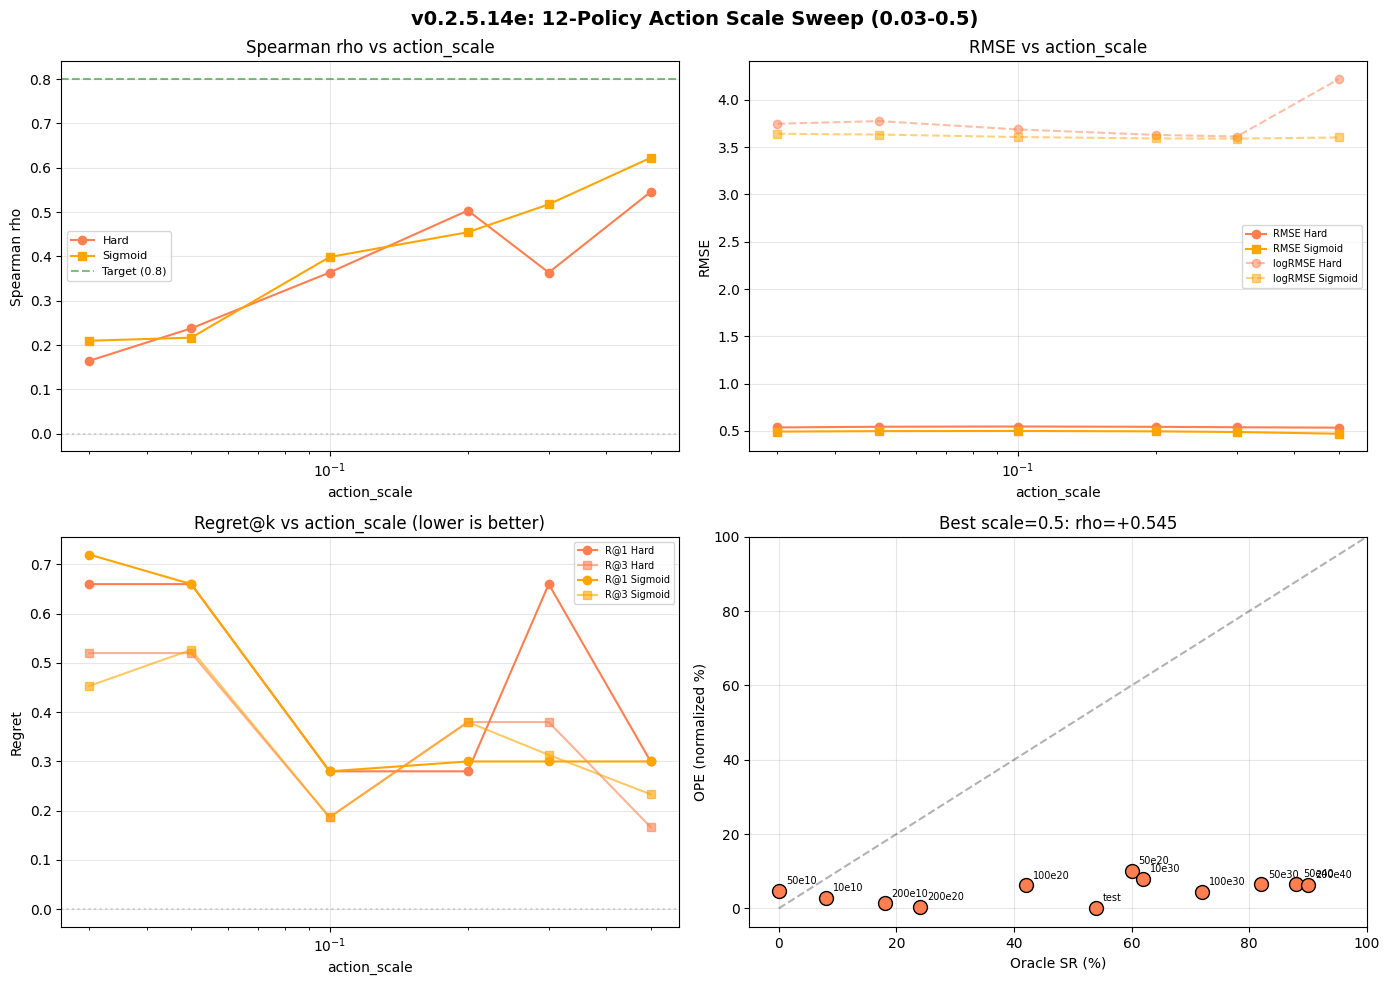

In [12]:
# ── Figure 1: Metrics vs action_scale ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scales = ACTION_SCALES

# Panel 1: Spearman rho
ax = axes[0, 0]
ax.plot(scales, [scale_metrics[s]["rho_hard"] for s in scales], 'o-', color="coral", label="Hard")
ax.plot(scales, [scale_metrics[s]["rho_sigm"] for s in scales], 's-', color="orange", label="Sigmoid")
ax.axhline(0.8, color="green", ls="--", alpha=0.5, label="Target (0.8)")
ax.axhline(0, color="gray", ls=":", alpha=0.3)
ax.set_xlabel("action_scale")
ax.set_ylabel("Spearman rho")
ax.set_title("Spearman rho vs action_scale")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xscale("log")

# Panel 2: RMSE
ax = axes[0, 1]
ax.plot(scales, [scale_metrics[s]["rmse_hard"] for s in scales], 'o-', color="coral", label="RMSE Hard")
ax.plot(scales, [scale_metrics[s]["rmse_sigm"] for s in scales], 's-', color="orange", label="RMSE Sigmoid")
ax.plot(scales, [scale_metrics[s]["log_rmse_hard"] for s in scales], 'o--', color="coral", alpha=0.5, label="logRMSE Hard")
ax.plot(scales, [scale_metrics[s]["log_rmse_sigm"] for s in scales], 's--', color="orange", alpha=0.5, label="logRMSE Sigmoid")
ax.set_xlabel("action_scale")
ax.set_ylabel("RMSE")
ax.set_title("RMSE vs action_scale")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_xscale("log")

# Panel 3: Regret@1 and @3
ax = axes[1, 0]
ax.plot(scales, [scale_metrics[s]["regret1_hard"] for s in scales], 'o-', color="coral", label="R@1 Hard")
ax.plot(scales, [scale_metrics[s]["regret3_hard"] for s in scales], 's-', color="coral", alpha=0.6, label="R@3 Hard")
ax.plot(scales, [scale_metrics[s]["regret1_sigm"] for s in scales], 'o-', color="orange", label="R@1 Sigmoid")
ax.plot(scales, [scale_metrics[s]["regret3_sigm"] for s in scales], 's-', color="orange", alpha=0.6, label="R@3 Sigmoid")
ax.axhline(0, color="gray", ls=":", alpha=0.3)
ax.set_xlabel("action_scale")
ax.set_ylabel("Regret")
ax.set_title("Regret@k vs action_scale (lower is better)")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_xscale("log")

# Panel 4: OPE scatter at best scale
ax = axes[1, 1]
best = best_scale
opes_best = np.array([sweep_results[(best, n)]["ope_hard"] / T_GEN for n in policy_names])
ax.scatter(oracle_srs * 100, opes_best * 100, s=100, c="coral", edgecolor="black", zorder=5)
for j, n in enumerate(policy_names):
    label = n.replace("demos_epoch", "e").replace("test_checkpoint", "test")
    ax.annotate(label, (oracle_srs[j]*100, opes_best[j]*100),
                textcoords="offset points", xytext=(5, 5), fontsize=7)
ax.plot([0, 100], [0, 100], 'k--', alpha=0.3)
ax.set_xlabel("Oracle SR (%)")
ax.set_ylabel("OPE (normalized %)")
ax.set_title(f"Best scale={best}: rho={scale_metrics[best]['rho_hard']:+.3f}")
ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 100)
ax.set_ylim(-5, 100)

fig.suptitle("v0.2.5.14e: 12-Policy Action Scale Sweep (0.03-0.5)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

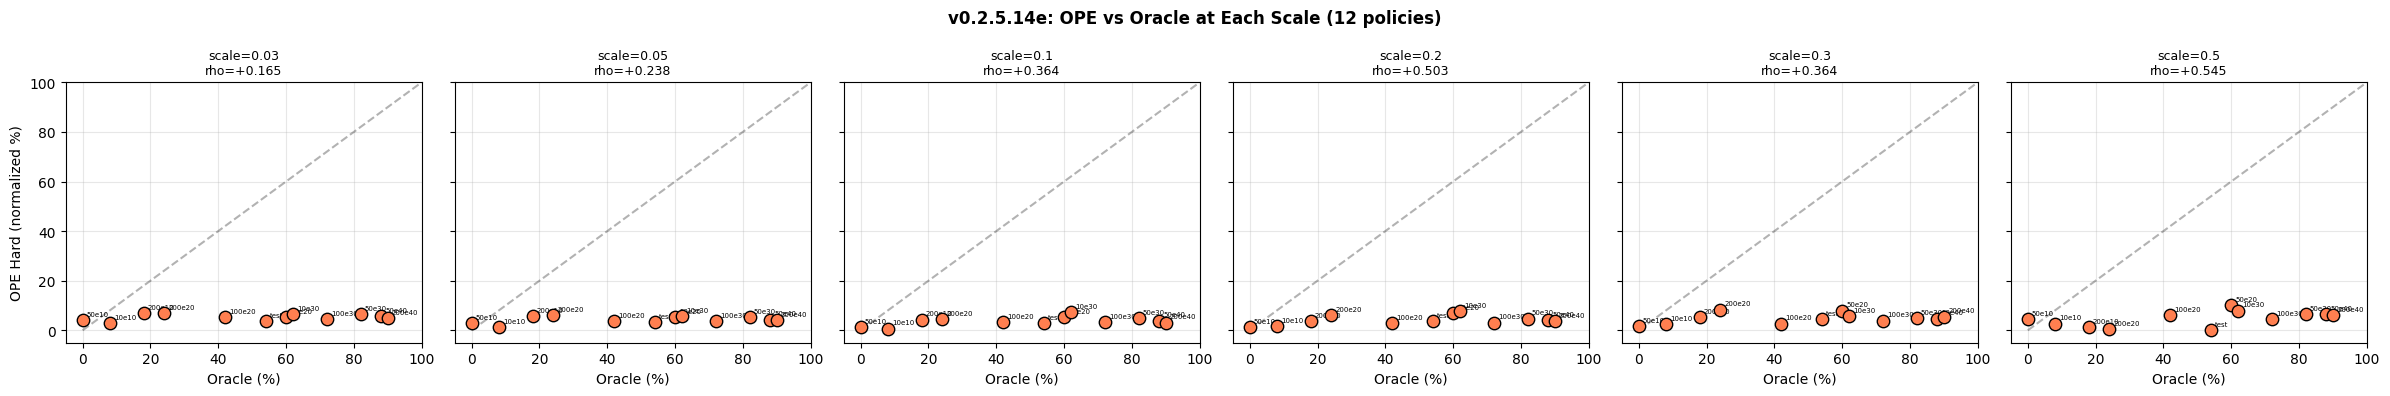

In [13]:
# ── Figure 2: OPE scatter at each scale ──
fig, axes = plt.subplots(1, len(ACTION_SCALES), figsize=(4*len(ACTION_SCALES), 4), sharey=True)

for ax, scale in zip(axes, ACTION_SCALES):
    opes = np.array([sweep_results[(scale, n)]["ope_hard"] / T_GEN for n in policy_names])
    m = scale_metrics[scale]
    ax.scatter(oracle_srs * 100, opes * 100, s=80, c="coral", edgecolor="black", zorder=5)
    ax.plot([0, 100], [0, 100], 'k--', alpha=0.3)
    for j, n in enumerate(policy_names):
        label = n.replace("demos_epoch", "e").replace("test_checkpoint", "test")
        ax.annotate(label, (oracle_srs[j]*100, opes[j]*100),
                    textcoords="offset points", xytext=(3, 3), fontsize=5)
    ax.set_xlabel("Oracle (%)")
    ax.set_title(f"scale={scale}\nrho={m['rho_hard']:+.3f}", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 100)
    ax.set_ylim(-5, 100)

axes[0].set_ylabel("OPE Hard (normalized %)")
fig.suptitle("v0.2.5.14e: OPE vs Oracle at Each Scale (12 policies)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

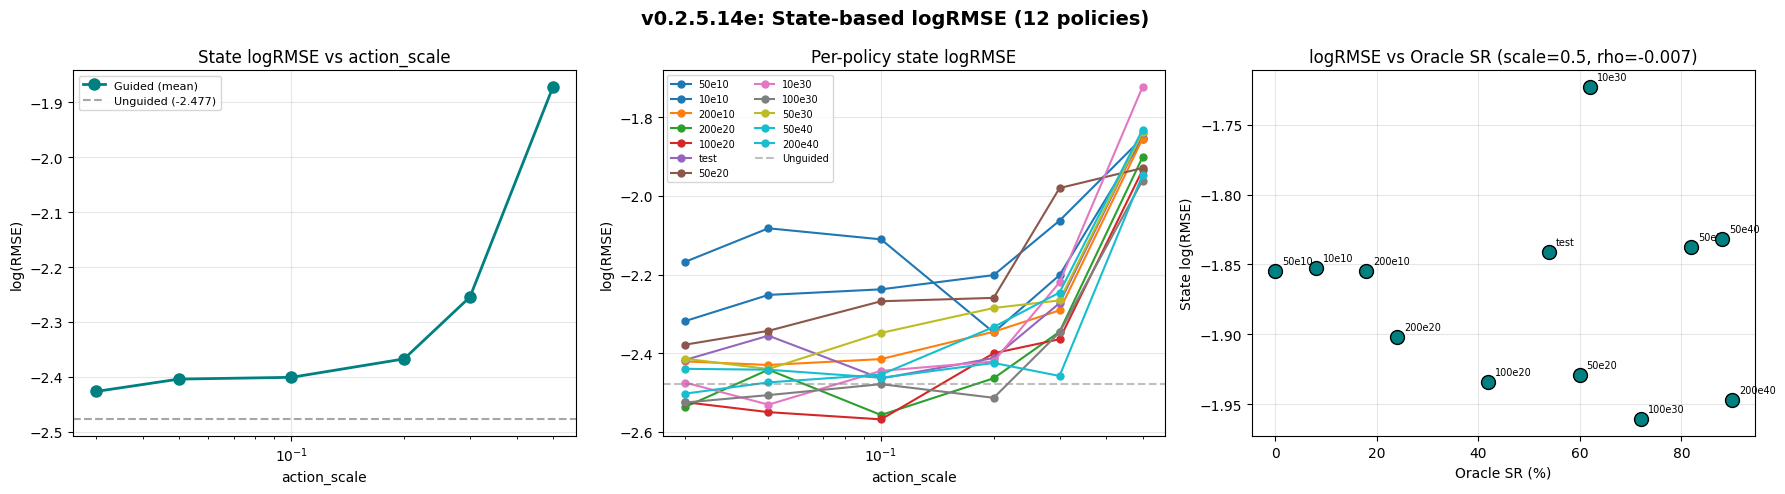

In [14]:
# ── Figure 3: State-based logRMSE ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scales = ACTION_SCALES

# Panel 1: Mean state logRMSE vs action_scale
ax = axes[0]
mean_lrs = [scale_metrics[s]["mean_state_log_rmse"] for s in scales]
ax.plot(scales, mean_lrs, 'o-', color="teal", linewidth=2, markersize=8, label="Guided (mean)")
ax.axhline(unguided_state_log_rmse, color="gray", ls="--", alpha=0.7, label=f"Unguided ({unguided_state_log_rmse:.3f})")
ax.set_xlabel("action_scale")
ax.set_ylabel("log(RMSE)")
ax.set_title("State logRMSE vs action_scale")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xscale("log")

# Panel 2: Per-policy state logRMSE across scales
ax = axes[1]
colors_pol = plt.cm.tab10(np.linspace(0, 1, len(policy_names)))
for j, name in enumerate(policy_names):
    lrs = [sweep_results[(s, name)]["state_log_rmse"] for s in scales]
    short = name.replace("demos_epoch", "e").replace("test_checkpoint", "test")
    ax.plot(scales, lrs, 'o-', color=colors_pol[j], label=short, markersize=5)
ax.axhline(unguided_state_log_rmse, color="gray", ls="--", alpha=0.5, label="Unguided")
ax.set_xlabel("action_scale")
ax.set_ylabel("log(RMSE)")
ax.set_title("Per-policy state logRMSE")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xscale("log")

# Panel 3: State logRMSE vs oracle SR at best scale
ax = axes[2]
best = max(ACTION_SCALES, key=lambda s: scale_metrics[s]["rho_hard"])
lrs_best = np.array([sweep_results[(best, n)]["state_log_rmse"] for n in policy_names])
ax.scatter(oracle_srs * 100, lrs_best, s=100, c="teal", edgecolor="black", zorder=5)
for j, n in enumerate(policy_names):
    short = n.replace("demos_epoch", "e").replace("test_checkpoint", "test")
    ax.annotate(short, (oracle_srs[j]*100, lrs_best[j]),
                textcoords="offset points", xytext=(5, 5), fontsize=7)
rho_lr, _ = stats.spearmanr(oracle_srs, -lrs_best)  # negative: lower logRMSE = better
ax.set_xlabel("Oracle SR (%)")
ax.set_ylabel("State log(RMSE)")
ax.set_title(f"logRMSE vs Oracle SR (scale={best}, rho={rho_lr:+.3f})")
ax.grid(True, alpha=0.3)

fig.suptitle("v0.2.5.14e: State-based logRMSE (12 policies)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()